In [1]:
import numpy as np
import torch
import torchvision
from PIL import Image

print("NumPy:", np.__version__)
print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Pillow:", Image.__version__)

NumPy: 1.26.4
Torch: 2.6.0+cu124
Torchvision: 0.21.0+cu124
Pillow: 9.5.0


In [2]:
!pip install facenet-pytorch==2.5.2
!pip install librosa==0.10.1
!pip install scikit-learn==1.2.2
!pip uninstall -y Pillow
!pip install Pillow==9.5.0

Found existing installation: Pillow 9.5.0
Uninstalling Pillow-9.5.0:
  Successfully uninstalled Pillow-9.5.0
  Using cached Pillow-9.5.0-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (9.5 kB)
Using cached Pillow-9.5.0-cp311-cp311-manylinux_2_28_x86_64.whl (3.4 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
scikit-image 0.25.2 requires pillow>=10.1, but you have pillow 9.5.0 which is incompatible.
gradio 5.38.1 requires pydantic<2.12,>=2.0, but you have pydantic 2.12.4 which is incompatible.
plotnine 0.14.5 requires matplotlib>=3.8.0, but you have matplotlib 3.7.2 which is in

In [3]:
# import IPython
# IPython.Application.instance().kernel.do_shutdown(True)

In [5]:
import os
import sys
import numpy as np
import cv2
import contextlib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import pandas as pd
import numpy as np
from pathlib import Path
import librosa
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
from sklearn.cluster import DBSCAN
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Import facenet_pytorch (should work now)
try:
    from facenet_pytorch import MTCNN, InceptionResnetV1
    print("✓ facenet_pytorch imported successfully")
except ImportError as e:
    print(f"Error importing facenet_pytorch: {e}")
    print("Trying alternative import method...")
    !pip install --force-reinstall facenet-pytorch==2.5.2
    from facenet_pytorch import MTCNN, InceptionResnetV1

from torchvision import transforms, models

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n{'='*60}")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"CUDA Version: {torch.version.cuda}")
print(f"{'='*60}\n")

✓ facenet_pytorch imported successfully

Using device: cuda
GPU: Tesla T4
VRAM: 15.83 GB
CUDA Version: 12.4



In [6]:
class Config:
    """Global configuration - MODIFY PATHS HERE"""
    # Dataset paths
    CSV_PATH = '/kaggle/input/dfdc-2-person-csv/CSV'
    VIDEO_ROOT = '/kaggle/input/dfdc-2-person-data/Data_2_people'
    
    # Model hyperparameters
    NUM_FRAMES = 8
    IMG_SIZE = 112
    MAX_IDENTITIES = 2
    
    # Training hyperparameters
    BATCH_SIZE = 4
    NUM_EPOCHS = 30
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-5
    
    # Audio parameters
    AUDIO_SR = 16000
    AUDIO_LENGTH = 10
    
    # Data splits
    TRAIN_SPLIT = 0.7
    VAL_SPLIT = 0.15
    TEST_SPLIT = 0.15
    
    # Training options
    SAVE_BEST_MODEL = True
    EARLY_STOPPING_PATIENCE = 5
    NUM_WORKERS = 2  # 0 for Kaggle compatibility
    PIN_MEMORY = True
    
    SEED = 42

config = Config()

print("Configuration:")
print(f"  CSV Path: {config.CSV_PATH}")
print(f"  Video Root: {config.VIDEO_ROOT}")
print(f"  Batch Size: {config.BATCH_SIZE}")
print(f"  Epochs: {config.NUM_EPOCHS}")
print(f"  Learning Rate: {config.LEARNING_RATE}\n")


Configuration:
  CSV Path: /kaggle/input/dfdc-2-person-csv/CSV
  Video Root: /kaggle/input/dfdc-2-person-data/Data_2_people
  Batch Size: 4
  Epochs: 30
  Learning Rate: 0.0001



In [7]:
print(f"{'='*70}")
print("LOADING METADATA & RESOLVING VIDEO PATHS")
print(f"{'='*70}\n")

# Load all CSV files
metadata_files = sorted([
    f for f in os.listdir(config.CSV_PATH)
    if f.startswith('metadata_') and f.endswith('.csv')
])
print(f"Found {len(metadata_files)} metadata files\n")

all_metadata = []
for meta_file in metadata_files:
    df = pd.read_csv(os.path.join(config.CSV_PATH, meta_file))
    all_metadata.append(df)
    print(f"  ✓ {meta_file}: {len(df)} rows")

metadata_df = pd.concat(all_metadata, ignore_index=True)
print(f"\nTotal CSV entries: {len(metadata_df)}")

# Function to find videos in subdirectories
def find_video_path(video_filename, video_root):
    """Search all subdirectories for video file"""
    if not os.path.exists(video_root):
        return None
    
    for subdir in os.listdir(video_root):
        subdir_path = os.path.join(video_root, subdir)
        if os.path.isdir(subdir_path):
            video_path = os.path.join(subdir_path, video_filename)
            if os.path.exists(video_path):
                return video_path
    return None

# Resolve video paths
print("\nSearching for videos in all subdirectories...")
tqdm.pandas(desc="Resolving paths")
metadata_df['full_video_path'] = metadata_df['Video Name'].progress_apply(
    lambda x: find_video_path(x, config.VIDEO_ROOT)
)

# Statistics
videos_found = metadata_df['full_video_path'].notna().sum()
videos_missing = len(metadata_df) - videos_found

print(f"\n{'='*70}")
print("VIDEO RESOLUTION RESULTS")
print(f"{'='*70}")
print(f"Total entries: {len(metadata_df)}")
print(f"Found:         {videos_found} ({videos_found/len(metadata_df)*100:.1f}%)")
print(f"Missing:       {videos_missing} ({videos_missing/len(metadata_df)*100:.1f}%)")

if videos_missing > 0:
    print(f"\nSample missing videos:")
    for i, vid in enumerate(metadata_df[metadata_df['full_video_path'].isna()]['Video Name'].head(5), 1):
        print(f"  {i}. {vid}")

# Filter missing
original_count = len(metadata_df)
metadata_df = metadata_df[metadata_df['full_video_path'].notna()].reset_index(drop=True)
print(f"\nFiltered missing: {original_count} → {len(metadata_df)} videos")

# ================================================================
# ✅ SUPPRESS FFmpeg ERRORS AND CHECK FOR CORRUPTED VIDEOS
# ================================================================

@contextlib.contextmanager
def suppress_stderr():
    """Suppress stderr to hide OpenCV/FFmpeg messages"""
    with open(os.devnull, 'w') as fnull:
        old_stderr = sys.stderr
        sys.stderr = fnull
        try:
            yield
        finally:
            sys.stderr = old_stderr

def is_video_valid(video_path, max_frames=1):
    """Check if video can be opened and first few frames are readable."""
    try:
        with suppress_stderr():
            cap = cv2.VideoCapture(video_path)
            if not cap.isOpened():
                return False

            frame_count = 0
            valid = False
            while frame_count < max_frames:
                ret, frame = cap.read()
                if not ret or frame is None:
                    valid = False
                    break
                valid = True
                frame_count += 1

            cap.release()
            return valid
    except:
        return False

print("\nChecking for corrupted or unreadable videos...")
metadata_df['is_valid'] = metadata_df['full_video_path'].apply(is_video_valid)

corrupt_count = (metadata_df['is_valid'] == False).sum()
print(f"\n❌ Corrupted or unreadable videos: {corrupt_count}")

# Remove corrupted videos
metadata_df = metadata_df[metadata_df['is_valid'] == True].reset_index(drop=True)
print(f"✓ Final usable videos: {len(metadata_df)}")

# ================================================================

# Verify sample valid paths
print("\n✓ Sample valid paths:")
for i, path in enumerate(metadata_df['full_video_path'].head(3), 1):
    folder = os.path.basename(os.path.dirname(path))
    filename = os.path.basename(path)
    print(f"  {i}. {folder}/{filename}")


LOADING METADATA & RESOLVING VIDEO PATHS

Found 31 metadata files

  ✓ metadata_00.csv: 13 rows
  ✓ metadata_01.csv: 0 rows
  ✓ metadata_02.csv: 395 rows
  ✓ metadata_03.csv: 229 rows
  ✓ metadata_04.csv: 352 rows
  ✓ metadata_05.csv: 594 rows
  ✓ metadata_06.csv: 507 rows
  ✓ metadata_07.csv: 354 rows
  ✓ metadata_08.csv: 52 rows
  ✓ metadata_09.csv: 230 rows
  ✓ metadata_10.csv: 398 rows
  ✓ metadata_11.csv: 106 rows
  ✓ metadata_12.csv: 462 rows
  ✓ metadata_13.csv: 609 rows
  ✓ metadata_14.csv: 70 rows
  ✓ metadata_15.csv: 8 rows
  ✓ metadata_16.csv: 230 rows
  ✓ metadata_17.csv: 154 rows
  ✓ metadata_18.csv: 99 rows
  ✓ metadata_19.csv: 11 rows
  ✓ metadata_20.csv: 339 rows
  ✓ metadata_21.csv: 43 rows
  ✓ metadata_22.csv: 114 rows
  ✓ metadata_23.csv: 377 rows
  ✓ metadata_24.csv: 69 rows
  ✓ metadata_25.csv: 63 rows
  ✓ metadata_26.csv: 313 rows
  ✓ metadata_27.csv: 38 rows
  ✓ metadata_28.csv: 168 rows
  ✓ metadata_29.csv: 234 rows
  ✓ metadata_30.csv: 183 rows

Total CSV entri

Resolving paths: 100%|██████████| 6814/6814 [00:12<00:00, 530.12it/s]



VIDEO RESOLUTION RESULTS
Total entries: 6814
Found:         6814 (100.0%)
Missing:       0 (0.0%)

Filtered missing: 6814 → 6814 videos

Checking for corrupted or unreadable videos...


[mov,mp4,m4a,3gp,3g2,mj2 @ 0x15e52440] moov atom not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x15ef5880] moov atom not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x15ef5880] moov atom not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x15ef5880] moov atom not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x15ecd3c0] moov atom not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x15ed1040] moov atom not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x15ecd3c0] moov atom not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x15e51d00] moov atom not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x15ecd3c0] moov atom not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x15e51d00] moov atom not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x15ecd3c0] moov atom not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x15e51d00] moov atom not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x15e5d6c0] moov atom not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x15ecd3c0] moov atom not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x15e5d6c0] moov atom not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x15ecd3c0] moov atom not found
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x15e5d6c0] moov atom not fou


❌ Corrupted or unreadable videos: 1647
✓ Final usable videos: 5167

✓ Sample valid paths:
  1. Videos_00/sxyrkshzsg.mp4
  2. Videos_00/qjvjkojjkl.mp4
  3. Videos_00/lclrhuuwnj.mp4


In [8]:
print(f"\n{'='*70}")
print("DATASET STATISTICS")
print(f"{'='*70}")
n_real_total = len(metadata_df[metadata_df['Label'] == 'REAL'])
n_fake_total = len(metadata_df[metadata_df['Label'] == 'FAKE'])
print(f"Total: {len(metadata_df)} videos")
print(f"Real:  {n_real_total} ({n_real_total/len(metadata_df)*100:.1f}%)")
print(f"Fake:  {n_fake_total} ({n_fake_total/len(metadata_df)*100:.1f}%)")
print(f"Ratio: 1:{n_fake_total/n_real_total:.1f} (Fake:Real)")

print(f"\n{'='*70}")
print("CREATING STRATIFIED SPLITS")
print(f"{'='*70}\n")

# Remove existing Split column if present
if 'Split' in metadata_df.columns:
    metadata_df = metadata_df.drop(columns=['Split'])

# Create stratified splits
train_df, temp_df = train_test_split(
    metadata_df,
    test_size=(config.VAL_SPLIT + config.TEST_SPLIT),
    random_state=config.SEED,
    stratify=metadata_df['Label']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=config.TEST_SPLIT / (config.VAL_SPLIT + config.TEST_SPLIT),
    random_state=config.SEED,
    stratify=temp_df['Label']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Split distribution:")
for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    n_real = len(split_df[split_df['Label'] == 'REAL'])
    n_fake = len(split_df[split_df['Label'] == 'FAKE'])
    print(f"  {split_name:5s}: {len(split_df):5d} | Real: {n_real:4d} ({n_real/len(split_df)*100:5.1f}%) | "
          f"Fake: {n_fake:4d} ({n_fake/len(split_df)*100:5.1f}%)")



DATASET STATISTICS
Total: 5167 videos
Real:  635 (12.3%)
Fake:  4532 (87.7%)
Ratio: 1:7.1 (Fake:Real)

CREATING STRATIFIED SPLITS

Split distribution:
  Train:  3616 | Real:  444 ( 12.3%) | Fake: 3172 ( 87.7%)
  Val  :   775 | Real:   95 ( 12.3%) | Fake:  680 ( 87.7%)
  Test :   776 | Real:   96 ( 12.4%) | Fake:  680 ( 87.6%)


In [9]:
print(f"\n{'='*70}")
print("CLASS IMBALANCE HANDLING")
print(f"{'='*70}\n")

n_real = len(train_df[train_df['Label'] == 'REAL'])
n_fake = len(train_df[train_df['Label'] == 'FAKE'])
total = len(train_df)

weight_real = total / (2 * n_real)
weight_fake = total / (2 * n_fake)
class_weights = torch.tensor([weight_real, weight_fake], dtype=torch.float32).to(device)

print(f"Training set:")
print(f"  Real: {n_real} ({n_real/total*100:.1f}%)")
print(f"  Fake: {n_fake} ({n_fake/total*100:.1f}%)")
print(f"\nClass weights (for loss function):")
print(f"  Real: {weight_real:.4f}")
print(f"  Fake: {weight_fake:.4f}")
print(f"\n→ Real videos penalized {weight_real/weight_fake:.2f}x more")


CLASS IMBALANCE HANDLING

Training set:
  Real: 444 (12.3%)
  Fake: 3172 (87.7%)

Class weights (for loss function):
  Real: 4.0721
  Fake: 0.5700

→ Real videos penalized 7.14x more


In [10]:
class FaceDetectorTracker:
    """Face detection and identity tracking using MTCNN + FaceNet"""
    def __init__(self, device='cuda', min_face_size=40, detection_threshold=0.9):
        self.device = device
        self.detection_threshold = detection_threshold
        
        self.mtcnn = MTCNN(
            keep_all=True,
            device=device,
            min_face_size=min_face_size,
            thresholds=[0.6, 0.7, 0.7],
            post_process=False
        )
        
        self.facenet = InceptionResnetV1(pretrained='vggface2').eval().to(device)
        print(f"✓ Face detector initialized")
        
    def detect_faces(self, frame):
        """Detect all faces in a frame"""
        try:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            boxes, probs = self.mtcnn.detect(frame_rgb)
            
            if boxes is None:
                return []
            
            faces_data = []
            h, w = frame.shape[:2]
            
            for box, prob in zip(boxes, probs):
                if prob > self.detection_threshold:
                    x1, y1, x2, y2 = [int(b) for b in box]
                    x1, y1 = max(0, x1), max(0, y1)
                    x2, y2 = min(w, x2), min(h, y2)
                    
                    if x2 > x1 and y2 > y1:
                        face_img = frame_rgb[y1:y2, x1:x2]
                        area_ratio = ((x2-x1) * (y2-y1)) / (w * h)
                        
                        faces_data.append({
                            'bbox': (x1, y1, x2, y2),
                            'face_img': face_img,
                            'area_ratio': area_ratio,
                            'confidence': float(prob)
                        })
            
            return faces_data
        except:
            return []
    
    def extract_face_embedding(self, face_img):
        """Extract face embedding for clustering"""
        try:
            face_tensor = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize((160, 160)),
                transforms.ToTensor(),
                transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
            ])(face_img).unsqueeze(0).to(self.device)
            
            with torch.no_grad():
                embedding = self.facenet(face_tensor).cpu().numpy().flatten()
            return embedding
        except:
            return None
    
    def cluster_faces(self, embeddings, min_samples=3):
        """Cluster faces into identities using DBSCAN"""
        if len(embeddings) < min_samples:
            return np.zeros(len(embeddings), dtype=int)
        
        clustering = DBSCAN(eps=0.45, min_samples=min_samples, metric='cosine')
        return clustering.fit_predict(embeddings)
    
    def process_video(self, video_path, max_frames=300, sample_rate=2):
        """Process video and extract face sequences per identity"""
        try:
            cap = cv2.VideoCapture(video_path)
            if not cap.isOpened():
                return {}
            
            fps = cap.get(cv2.CAP_PROP_FPS)
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            
            all_faces = []
            sample_indices = list(range(0, min(total_frames, max_frames), sample_rate))
            
            for idx in sample_indices:
                cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
                ret, frame = cap.read()
                if not ret:
                    break
                
                faces = self.detect_faces(frame)
                for face_data in faces:
                    face_data['frame_idx'] = idx
                    face_data['timestamp'] = idx / fps if fps > 0 else idx
                    all_faces.append(face_data)
            
            cap.release()
            
            if len(all_faces) == 0:
                return {}
            
            # Extract embeddings and cluster
            embeddings = []
            valid_faces = []
            
            for face_data in all_faces:
                emb = self.extract_face_embedding(face_data['face_img'])
                if emb is not None:
                    embeddings.append(emb)
                    valid_faces.append(face_data)
            
            if len(embeddings) == 0:
                return {}
            
            embeddings_array = np.array(embeddings)
            identity_labels = self.cluster_faces(embeddings_array)
            
            # Organize by identity
            identities = {}
            for face_data, identity_id in zip(valid_faces, identity_labels):
                if identity_id == -1:
                    continue
                
                if identity_id not in identities:
                    identities[identity_id] = []
                identities[identity_id].append(face_data)
            
            # Keep top identities by size
            identity_sizes = {
                id: np.mean([f['area_ratio'] for f in faces]) 
                for id, faces in identities.items()
            }
            sorted_identities = sorted(identity_sizes.items(), key=lambda x: x[1], reverse=True)
            top_identities = {id: identities[id] for id, _ in sorted_identities[:config.MAX_IDENTITIES]}
            
            return top_identities
            
        except:
            return {}


In [11]:
class AudioProcessor:
    """Audio extraction and speech activity detection"""
    def __init__(self, sr=16000):
        self.sr = sr
        print(f"✓ Audio processor initialized")
    
    def extract_audio(self, video_path):
        """Extract audio waveform from video"""
        try:
            audio, sr = librosa.load(video_path, sr=self.sr, mono=True)
            return audio
        except:
            return None
    
    def detect_speech_activity(self, audio, frame_length=2048, hop_length=512):
        """Detect speech segments"""
        if audio is None or len(audio) == 0:
            return []
        
        try:
            energy = librosa.feature.rms(y=audio, frame_length=frame_length, hop_length=hop_length)[0]
            threshold = np.mean(energy) + 0.5 * np.std(energy)
            speech_frames = energy > threshold
            times = librosa.frames_to_time(np.arange(len(speech_frames)), sr=self.sr, hop_length=hop_length)
            
            segments = []
            in_speech = False
            start_time = 0
            
            for i, is_speech in enumerate(speech_frames):
                if is_speech and not in_speech:
                    start_time = times[i]
                    in_speech = True
                elif not is_speech and in_speech:
                    segments.append((start_time, times[i]))
                    in_speech = False
            
            return segments
        except:
            return []


In [12]:
class SpeakerFaceAssociator:
    """Associates faces with speech based on lip movement"""
    def compute_lip_activity(self, face_sequence, max_comparisons=10):
        """Compute lip movement intensity"""
        if len(face_sequence) < 2:
            return 0.0
        
        activities = []
        num_comparisons = min(len(face_sequence) - 1, max_comparisons)
        
        for i in range(num_comparisons):
            try:
                face1 = cv2.resize(face_sequence[i]['face_img'], (64, 64))
                face2 = cv2.resize(face_sequence[i + 1]['face_img'], (64, 64))
                
                gray1 = cv2.cvtColor(face1, cv2.COLOR_RGB2GRAY)
                gray2 = cv2.cvtColor(face2, cv2.COLOR_RGB2GRAY)
                
                h = gray1.shape[0]
                mouth1 = gray1[h//2:, :]
                mouth2 = gray2[h//2:, :]
                
                diff = np.abs(mouth1.astype(float) - mouth2.astype(float))
                activities.append(np.mean(diff))
            except:
                continue
        
        return np.mean(activities) if activities else 0.0
    
    def associate(self, identities, audio, speech_segments, fps=30):
        """Associate identities with speech"""
        if len(identities) == 0 or audio is None or len(speech_segments) == 0:
            return {id: False for id in identities.keys()}
        
        lip_activities = {
            identity_id: self.compute_lip_activity(face_sequence)
            for identity_id, face_sequence in identities.items()
        }
        
        if len(lip_activities) == 0:
            return {}
        
        speaking_id = max(lip_activities.items(), key=lambda x: x[1])[0]
        return {id: (id == speaking_id) for id in identities.keys()}


In [13]:
class MultiIdentityDataset(Dataset):
    """Dataset that automatically skips missing/invalid videos"""
    def __init__(self, metadata_df, face_detector, audio_processor,
                 num_frames=8, img_size=112, max_identities=2):
        # Only keep valid paths
        self.metadata = metadata_df[metadata_df['full_video_path'].notna()].reset_index(drop=True)
        self.face_detector = face_detector
        self.audio_processor = audio_processor
        self.speaker_associator = SpeakerFaceAssociator()
        self.num_frames = num_frames
        self.img_size = img_size
        self.max_identities = max_identities
        
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        
        self.failed_videos = []
        print(f"✓ Dataset: {len(self.metadata)} videos")
    
    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        video_path = row['full_video_path']
        label = 1 if row['Label'] == 'FAKE' else 0
        
        if not os.path.exists(video_path):
            self.failed_videos.append(os.path.basename(video_path))
            return self._get_dummy_sample(label)
        
        try:
            # Process video
            identities = self.face_detector.process_video(video_path)
            
            if len(identities) == 0:
                self.failed_videos.append(f"{os.path.basename(video_path)} (no faces)")
                return self._get_dummy_sample(label)
            
            # Extract audio
            audio = self.audio_processor.extract_audio(video_path)
            speech_segments = self.audio_processor.detect_speech_activity(audio) if audio is not None else []
            speaker_map = self.speaker_associator.associate(identities, audio, speech_segments)
            
            # Prepare face sequences
            face_sequences = []
            is_speaking = []
            
            for identity_id in sorted(identities.keys())[:self.max_identities]:
                faces = identities[identity_id]
                
                if len(faces) >= self.num_frames:
                    indices = np.linspace(0, len(faces)-1, self.num_frames, dtype=int)
                    sampled_faces = [faces[i] for i in indices]
                else:
                    sampled_faces = faces + [faces[-1]] * (self.num_frames - len(faces))
                
                face_tensors = [self.transform(cv2.resize(f['face_img'], (self.img_size, self.img_size))) 
                              for f in sampled_faces]
                face_sequences.append(torch.stack(face_tensors))
                is_speaking.append(speaker_map.get(identity_id, False))
            
            # Pad if needed
            while len(face_sequences) < self.max_identities:
                face_sequences.append(torch.zeros(self.num_frames, 3, self.img_size, self.img_size))
                is_speaking.append(False)
            
            face_sequences = torch.stack(face_sequences)
            is_speaking = torch.tensor(is_speaking, dtype=torch.float32)
            
            # Process audio
            if audio is not None:
                target_length = config.AUDIO_SR * config.AUDIO_LENGTH
                if len(audio) > target_length:
                    audio = audio[:target_length]
                else:
                    audio = np.pad(audio, (0, target_length - len(audio)))
                audio_tensor = torch.tensor(audio, dtype=torch.float32)
            else:
                audio_tensor = torch.zeros(config.AUDIO_SR * config.AUDIO_LENGTH, dtype=torch.float32)
            
            return face_sequences, audio_tensor, is_speaking, label
            
        except Exception as e:
            self.failed_videos.append(f"{os.path.basename(video_path)} ({str(e)[:50]})")
            return self._get_dummy_sample(label)
    
    def _get_dummy_sample(self, label):
        """Fallback dummy sample"""
        face_sequences = torch.zeros(self.max_identities, self.num_frames, 3, self.img_size, self.img_size)
        audio_tensor = torch.zeros(config.AUDIO_SR * config.AUDIO_LENGTH)
        is_speaking = torch.zeros(self.max_identities)
        return face_sequences, audio_tensor, is_speaking, label


In [14]:
class LightweightVisualBackbone(nn.Module):
    """MobileNetV3-Small for efficient face feature extraction"""
    def __init__(self):
        super().__init__()
        mobilenet = models.mobilenet_v3_small(pretrained=True)
        self.features = mobilenet.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.feature_dim = 576
    
    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return x.flatten(1)

class TemporalEncoder(nn.Module):
    """BiLSTM for temporal modeling"""
    def __init__(self, input_dim=576, hidden_dim=256, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, 
                          bidirectional=True, batch_first=True, dropout=0.2)
        self.output_dim = hidden_dim * 2
    
    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        return torch.cat([hn[-2], hn[-1]], dim=1)

class AudioEncoder(nn.Module):
    """Lightweight 1D CNN for audio encoding"""
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 64, 80, 16), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(64, 128, 3, 1, 1), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(128, 256, 3, 1, 1), nn.BatchNorm1d(256), nn.ReLU(), nn.AdaptiveAvgPool1d(1)
        )
        self.output_dim = 256
    
    def forward(self, x):
        return self.encoder(x.unsqueeze(1)).squeeze(-1)

class CrossModalAttention(nn.Module):
    """Identity-conditioned cross-modal attention"""
    def __init__(self, visual_dim=512, audio_dim=256, num_heads=4):
        super().__init__()
        self.attention = nn.MultiheadAttention(visual_dim, num_heads, 0.1, batch_first=True)
        self.audio_projection = nn.Linear(audio_dim, visual_dim)
        self.norm = nn.LayerNorm(visual_dim)
    
    def forward(self, visual_features, audio_features, is_speaking_mask):
        audio_proj = self.audio_projection(audio_features).unsqueeze(1)
        audio_expanded = audio_proj.expand(-1, visual_features.size(1), -1)
        
        attended_features = []
        for i in range(visual_features.size(1)):
            attn_out, _ = self.attention(visual_features[:, i:i+1, :], 
                                        audio_expanded[:, i:i+1, :], 
                                        audio_expanded[:, i:i+1, :])
            attended_features.append(attn_out.squeeze(1))
        
        attended_features = torch.stack(attended_features, dim=1)
        is_speaking_mask = is_speaking_mask.unsqueeze(-1)
        output = visual_features * (1 - is_speaking_mask) + attended_features * is_speaking_mask
        return self.norm(output)

class MultiIdentityDeepfakeDetector(nn.Module):
    """Complete multimodal deepfake detector"""
    def __init__(self, num_identities=2, num_frames=8):
        super().__init__()
        self.visual_backbone = LightweightVisualBackbone()
        self.temporal_encoder = TemporalEncoder()
        self.audio_encoder = AudioEncoder()
        self.cross_attention = CrossModalAttention()
        self.classifier = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 2)
        )
    
    def forward(self, face_sequences, audio, is_speaking):
        B, N, T = face_sequences.shape[:3]
        
        identity_features = []
        for i in range(N):
            faces_flat = face_sequences[:, i].reshape(B*T, *face_sequences.shape[3:])
            visual_feats = self.visual_backbone(faces_flat).view(B, T, -1)
            temporal_feats = self.temporal_encoder(visual_feats)
            identity_features.append(temporal_feats)
        
        identity_features = torch.stack(identity_features, dim=1)
        audio_features = self.audio_encoder(audio)
        fused_features = self.cross_attention(identity_features, audio_features, is_speaking)
        
        identity_preds = torch.stack([self.classifier(fused_features[:, i]) for i in range(N)], dim=1)
        video_pred = torch.max(identity_preds[:, :, 1], dim=1)[0]
        
        return identity_preds, video_pred


In [15]:
def train_epoch(model, dataloader, criterion, optimizer, scaler, device):
    """Train for one epoch"""
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for faces, audio, speaking, labels in tqdm(dataloader, desc="Training", leave=False):
        faces, audio, speaking, labels = faces.to(device), audio.to(device), speaking.to(device), labels.to(device)
        optimizer.zero_grad()
        
        with autocast():
            _, video_pred = model(faces, audio, speaking)
            loss = criterion(torch.stack([1-video_pred, video_pred], dim=1), labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        preds = (video_pred > 0.5).long()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    return total_loss / len(dataloader), correct / total

def validate(model, dataloader, criterion, device):
    """Validate with comprehensive metrics"""
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []
    
    with torch.no_grad():
        for faces, audio, speaking, labels in tqdm(dataloader, desc="Validation", leave=False):
            faces, audio, speaking, labels = faces.to(device), audio.to(device), speaking.to(device), labels.to(device)
            
            with autocast():
                _, video_pred = model(faces, audio, speaking)
                loss = criterion(torch.stack([1-video_pred, video_pred], dim=1), labels)
            
            total_loss += loss.item()
            all_preds.extend((video_pred > 0.5).long().cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(video_pred.cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average=None, zero_division=0)
    balanced_acc = balanced_accuracy_score(all_labels, all_preds)
    
    return {
        'loss': total_loss / len(dataloader),
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'auc': auc,
        'f1_real': f1[0] if len(f1) > 0 else 0,
        'f1_fake': f1[1] if len(f1) > 1 else 0,
    }, all_preds, all_labels, all_probs

In [16]:
print(f"\n{'='*70}")
print("INITIALIZING COMPONENTS")
print(f"{'='*70}\n")

face_detector = FaceDetectorTracker(device=device)
audio_processor = AudioProcessor(sr=config.AUDIO_SR)

print(f"\n{'='*70}")
print("CREATING DATASETS")
print(f"{'='*70}\n")

# Use subset for testing (set to None for full training)
TRAIN_SUBSET = None  # None for full
VAL_SUBSET = None     # None for full

train_subset = train_df[:TRAIN_SUBSET] if TRAIN_SUBSET else train_df
val_subset = val_df[:VAL_SUBSET] if VAL_SUBSET else val_df

print(f"Training: {len(train_subset)} videos")
print(f"Validation: {len(val_subset)} videos\n")

train_dataset = MultiIdentityDataset(train_subset, face_detector, audio_processor,
                                    config.NUM_FRAMES, config.IMG_SIZE, config.MAX_IDENTITIES)
val_dataset = MultiIdentityDataset(val_subset, face_detector, audio_processor,
                                  config.NUM_FRAMES, config.IMG_SIZE, config.MAX_IDENTITIES)

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, 
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, 
                        num_workers=2, pin_memory=True)

print(f"Batches: {len(train_loader)} train, {len(val_loader)} val")

# Test one sample
# print("\nTesting data loading...")
# sample = train_dataset[0]
# faces, audio, speaking, label = sample
# print(f"✓ Sample: faces={faces.shape}, audio={audio.shape}, label={'FAKE' if label else 'REAL'}")
# print(f"  Non-zero pixels: {(faces != 0).sum().item()}/{faces.numel()} ({(faces != 0).sum().item()/faces.numel()*100:.1f}%)")

# if (faces == 0).all():
#     print("\n⚠ WARNING: All zeros! Check video processing.")
# else:
#     print("✓ Real data loaded successfully!")



INITIALIZING COMPONENTS

✓ Face detector initialized
✓ Audio processor initialized

CREATING DATASETS

Training: 3616 videos
Validation: 775 videos

✓ Dataset: 3616 videos
✓ Dataset: 775 videos
Batches: 904 train, 194 val


In [17]:
print(f"\n{'='*70}")
print("INITIALIZING MODEL")
print(f"{'='*70}\n")

model = MultiIdentityDeepfakeDetector(config.MAX_IDENTITIES, config.NUM_FRAMES).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,} (~{total_params * 4 / 1e6:.1f} MB)")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.NUM_EPOCHS)
scaler = GradScaler()

print(f"✓ Weighted loss: Real={class_weights[0]:.2f}, Fake={class_weights[1]:.2f}")


INITIALIZING MODEL

Parameters: 5,689,058 (~22.8 MB)
✓ Weighted loss: Real=4.07, Fake=0.57


In [18]:
print(f"\n{'='*70}")
print("TRAINING")
print(f"{'='*70}\n")

history = {k: [] for k in ['train_loss', 'train_acc', 'val_loss', 'val_acc', 
                           'val_balanced_acc', 'val_auc', 'val_f1_real', 'val_f1_fake']}

best_bal_acc = 0
best_epoch = 0
patience = 0

for epoch in range(config.NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{config.NUM_EPOCHS}")
    print("-" * 70)
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, scaler, device)
    val_metrics, _, _, _ = validate(model, val_loader, criterion, device)
    scheduler.step()
    
    for k, v in zip(['train_loss', 'train_acc'], [train_loss, train_acc]):
        history[k].append(v)
    for k in ['val_loss', 'val_acc', 'val_balanced_acc', 'val_auc', 'val_f1_real', 'val_f1_fake']:
        history[k].append(val_metrics[k.replace('val_', '')])
    
    print(f"Train: Loss={train_loss:.4f} Acc={train_acc:.4f}")
    print(f"Val:   Loss={val_metrics['loss']:.4f} Acc={val_metrics['accuracy']:.4f} "
          f"BalAcc={val_metrics['balanced_accuracy']:.4f}")
    print(f"       AUC={val_metrics['auc']:.4f} F1: Real={val_metrics['f1_real']:.4f} Fake={val_metrics['f1_fake']:.4f}")
    
    if val_metrics['balanced_accuracy'] > best_bal_acc:
        best_bal_acc = val_metrics['balanced_accuracy']
        best_epoch = epoch + 1
        patience = 0
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                   'val_balanced_acc': best_bal_acc}, 'best_model.pth')
        print(f"  ✓ Best model saved!")
    else:
        patience += 1
    
    if patience >= config.EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print(f"\n✓ Training complete! Best BalAcc: {best_bal_acc:.4f} (Epoch {best_epoch})")


TRAINING


Epoch 1/30
----------------------------------------------------------------------


Training:   0%|          | 2/904 [06:46<41:56:02, 167.36s/it] [h264 @ 0x1be3c780] A non-intra slice in an IDR NAL unit.
[h264 @ 0x1be3c780] decode_slice_header error
[NULL @ 0x15f3d300] Invalid NAL unit size (-1517271484 > 2776).
[NULL @ 0x15f3d300] missing picture in access unit with size 2780
[h264 @ 0x1be3c780] A non-intra slice in an IDR NAL unit.
[h264 @ 0x1be3c780] decode_slice_header error
[NULL @ 0x15f3d300] Invalid NAL unit size (208615947 > 2888).
[NULL @ 0x15f3d300] missing picture in access unit with size 2892
[h264 @ 0x1b7450c0] Invalid NAL unit size (-1517271484 > 2776).
[h264 @ 0x1b7450c0] Error splitting the input into NAL units.
[h264 @ 0x1abdbb40] Invalid NAL unit size (208615947 > 2888).
[h264 @ 0x1abdbb40] Error splitting the input into NAL units.
[NULL @ 0x15f3d300] Invalid NAL unit size (-1517271484 > 2776).
[NULL @ 0x15f3d300] missing picture in access unit with size 2780
[h264 @ 0x1be3c780] A non-intra slice in an IDR NAL unit.
[h264 @ 0x1be3c780] decode_slice_h

KeyboardInterrupt: 

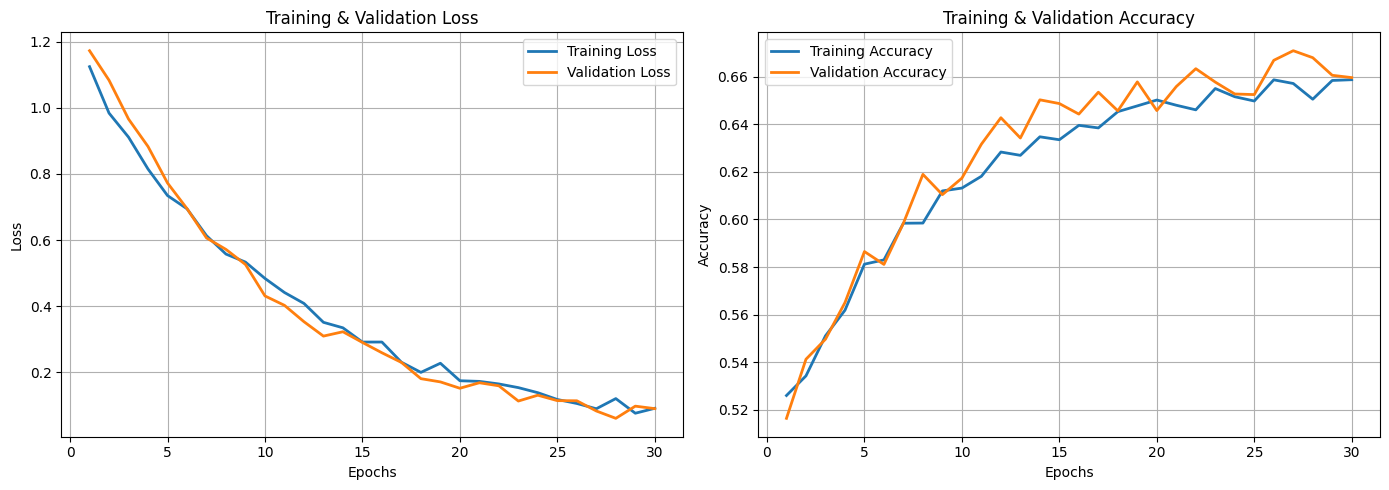

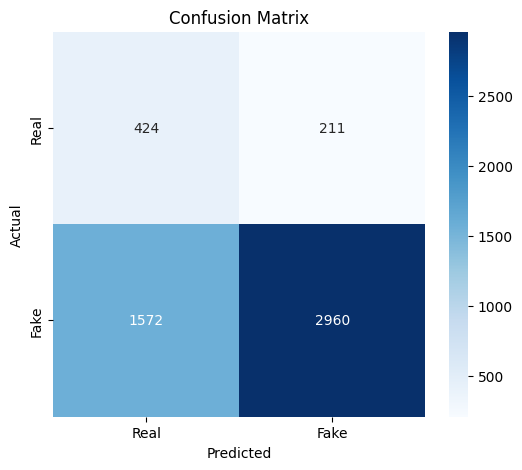

Confusion Matrix:
 [[ 424  211]
 [1572 2960]]


In [26]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.plot(history['train_loss'], 'o-', label='Train')
plt.plot(history['val_loss'], 's-', label='Val')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss')
plt.legend(); plt.grid(alpha=0.3)

plt.subplot(2, 3, 2)
plt.plot(history['train_acc'], 'o-', label='Train Acc')
plt.plot(history['val_acc'], 's-', label='Val Acc')
plt.plot(history['val_balanced_acc'], '^-', label='Val Balanced Acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy')
plt.legend(); plt.grid(alpha=0.3)

plt.subplot(2, 3, 3)
plt.plot(history['val_auc'], 's-', color='green')
plt.axhline(max(history['val_auc']), color='r', linestyle='--', label=f'Best: {max(history["val_auc"]):.3f}')
plt.xlabel('Epoch'); plt.ylabel('AUC'); plt.title('Validation AUC')
plt.legend(); plt.grid(alpha=0.3)

plt.subplot(2, 3, 4)
plt.plot(history['val_f1_real'], 'o-', label='Real')
plt.plot(history['val_f1_fake'], 's-', label='Fake')
plt.xlabel('Epoch'); plt.ylabel('F1 Score'); plt.title('F1 Scores')
plt.legend(); plt.grid(alpha=0.3)

plt.subplot(2, 3, 5)
plt.plot(history['val_balanced_acc'], '^-', color='purple')
plt.axhline(best_bal_acc, color='r', linestyle='--', label=f'Best: {best_bal_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Balanced Acc'); plt.title('Balanced Accuracy')
plt.legend(); plt.grid(alpha=0.3)

plt.subplot(2, 3, 6)
stats_text = f'Dataset: {len(metadata_df)} videos\n' \
             f'Real: {n_real_total} ({n_real_total/len(metadata_df)*100:.1f}%)\n' \
             f'Fake: {n_fake_total} ({n_fake_total/len(metadata_df)*100:.1f}%)\n' \
             f'Ratio: 1:{n_fake_total/n_real_total:.1f}\n\n' \
             f'Using weighted loss &\nbalanced accuracy'
plt.text(0.5, 0.5, stats_text, ha='center', va='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.axis('off'); plt.title('Dataset Stats')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved training_curves.png")

In [ ]:
print(f"\n{'='*70}")
print("TEST EVALUATION")
print(f"{'='*70}\n")

checkpoint = torch.load('best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✓ Loaded best model (Epoch {checkpoint['epoch']+1})")

TEST_SUBSET = None  # None for full
test_subset = test_df[:TEST_SUBSET] if TEST_SUBSET else test_df

test_dataset = MultiIdentityDataset(test_subset, face_detector, audio_processor,
                                   config.NUM_FRAMES, config.IMG_SIZE, config.MAX_IDENTITIES)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=2)

test_metrics, test_preds, test_labels, test_probs = validate(model, test_loader, criterion, device)

print(f"\n{'='*70}")
print("TEST RESULTS")
print(f"{'='*70}")
print(f"Loss:         {test_metrics['loss']:.4f}")
print(f"Accuracy:     {test_metrics['accuracy']:.4f}")
print(f"Balanced Acc: {test_metrics['balanced_accuracy']:.4f} ⭐")
print(f"AUC:          {test_metrics['auc']:.4f}")
print(f"F1 Real:      {test_metrics['f1_real']:.4f}")
print(f"F1 Fake:      {test_metrics['f1_fake']:.4f}")

print(f"\n{classification_report(test_labels, test_preds, target_names=['Real', 'Fake'], digits=4)}")

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix'); plt.ylabel('True'); plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved confusion_matrix.png")

print(f"\n{'='*70}")
print("✓ COMPLETE!")
print(f"{'='*70}")